# Bures and Fisher--Rao Geodesics in the Covariance Cone

This notebook generates `fig:monge-gaussian-fr-vs-bures-cone`.  For centered Gaussian laws, two natural geometries can be placed on the cone of covariance matrices.  The Bures--Wasserstein geometry is induced by optimal transport:
$$
\mathcal B^2(\Sigma_0,\Sigma_1)=\operatorname{tr}\!\left(\Sigma_0+\Sigma_1-2(\Sigma_0^{1/2}\Sigma_1\Sigma_0^{1/2})^{1/2}\right),
$$
whereas the Fisher--Rao, or affine-invariant, geometry is the local quadratic geometry of the Gaussian Kullback--Leibler divergence:
$$
g_\Sigma(D,D)=\frac12\operatorname{tr}(\Sigma^{-1}D\Sigma^{-1}D).
$$
For $2\times2$ covariances, the coordinates
$$
t=\frac{a+b}{\sqrt2},\qquad u=\frac{a-b}{\sqrt2},\qquad v=\sqrt2c,
\quad \Sigma=\begin{pmatrix}a&c\\c&b\end{pmatrix},
$$
identify the positive semidefinite cone with the Lorentz cone $t\geq\sqrt{u^2+v^2}$.  The Bures panel transports an interior covariance to a rank-one covariance on the boundary.  The Fisher--Rao panel uses a small positive-definite regularization of the same rank-one limit, because that boundary is at infinite Fisher--Rao distance.


In [1]:
from pathlib import Path
import sys
import shutil
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "notebooks-figures"))

from figure_style import (
    RED, BLUE, VIOLET, ORANGE, GRAY, LIGHT_GRAY,
    DIRAC_MARKER_SIZE, setup_matplotlib, figure_dir, save_pdf,
    interp_color,
)

setup_matplotlib()

NAME = "monge-gaussian-fr-vs-bures-cone"
OUT = figure_dir(NAME)
THUMBNAIL = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
ARXIV_OUT = ROOT / "arxiv" / "figures"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)


def symmetrize(S):
    return 0.5 * (S + S.T)


def sqrtm_spd(S):
    w, V = np.linalg.eigh(symmetrize(S))
    return (V * np.sqrt(np.maximum(w, 0.0))) @ V.T


def invsqrtm_spd(S):
    w, V = np.linalg.eigh(symmetrize(S))
    return (V * (1.0 / np.sqrt(np.maximum(w, 1e-15)))) @ V.T


def spd_power(S, power):
    w, V = np.linalg.eigh(symmetrize(S))
    return (V * (np.maximum(w, 1e-15) ** power)) @ V.T


def rotation(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])


def covariance(theta_deg, lam1, lam2):
    R = rotation(np.deg2rad(theta_deg))
    return R @ np.diag([lam1, lam2]) @ R.T


def gaussian_w2_covariances(S0, S1, ts):
    S0h = sqrtm_spd(S0)
    A = invsqrtm_spd(S0) @ sqrtm_spd(S0h @ S1 @ S0h) @ invsqrtm_spd(S0)
    out = []
    for t in ts:
        B = (1 - t) * np.eye(2) + t * A
        out.append(symmetrize(B @ S0 @ B.T))
    return out


def fisher_rao_covariances(S0, S1, ts):
    S0h = sqrtm_spd(S0)
    S0ih = invsqrtm_spd(S0)
    M = symmetrize(S0ih @ S1 @ S0ih)
    out = []
    for t in ts:
        out.append(symmetrize(S0h @ spd_power(M, t) @ S0h))
    return out


def psd_cone_coords(S):
    "Return orthonormal cone coordinates (u, v, t) for a 2x2 covariance."
    a = float(S[0, 0])
    b = float(S[1, 1])
    c = float(S[0, 1])
    return np.array([(a - b) / np.sqrt(2.0), np.sqrt(2.0) * c, (a + b) / np.sqrt(2.0)])


# Three geodesic tests.  Two starts are already close to the cone boundary,
# making the Bures completion and Fisher--Rao boundary repulsion visible.
GEODESIC_CASES = [
    (covariance(-38.0, 0.92, 0.120), covariance(52.0, 0.82, 0.000), covariance(52.0, 0.82, 0.070)),
    (covariance(18.0, 0.72, 0.030), covariance(-68.0, 0.74, 0.000), covariance(-68.0, 0.74, 0.050)),
    (covariance(84.0, 0.56, 0.045), covariance(6.0, 0.94, 0.000), covariance(6.0, 0.94, 0.055)),
]

ts_path = np.linspace(0.0, 1.0, 181)
PATHS = {
    "bures-cone.pdf": {
        "paths": [
            {"covariances": gaussian_w2_covariances(S0, S_boundary, ts_path)}
            for S0, S_boundary, _ in GEODESIC_CASES
        ],
    },
    "fisher-rao-cone.pdf": {
        "paths": [
            {
                "covariances": fisher_rao_covariances(S0, S_regularized, ts_path),
                "boundary_limit": S_boundary,
            }
            for S0, S_boundary, S_regularized in GEODESIC_CASES
        ],
    },
}


## Cone rendering

The gray chord is the Euclidean segment in the ambient coordinates $(u,v,t)$, while the colored curve is the geodesic for the chosen covariance geometry.  In the Fisher--Rao panel, the open boundary marker is the singular rank-one covariance reached by Bures but not by any finite Fisher--Rao geodesic.


In [2]:
def draw_colored_3d_path(ax, coords, ts, *, lw=1.65, alpha=0.96):
    coords = np.asarray(coords)
    ts = np.asarray(ts)
    for k in range(len(coords) - 1):
        tm = 0.5 * (float(ts[k]) + float(ts[k + 1]))
        ax.plot(
            coords[k:k+2, 0], coords[k:k+2, 1], coords[k:k+2, 2],
            color=interp_color(tm), lw=lw, alpha=alpha,
            solid_capstyle="round", zorder=5,
        )


def draw_euclidean_chord(ax, coords, boundary_coords=None):
    coords = np.asarray(coords)
    end = coords[-1] if boundary_coords is None else np.asarray(boundary_coords)
    ax.plot(
        [coords[0, 0], end[0]],
        [coords[0, 1], end[1]],
        [coords[0, 2], end[2]],
        color="#8a8175", lw=0.75, alpha=0.38,
        linestyle=(0, (1.1, 2.0)), zorder=3,
    )


def draw_boundary_limit(ax, S):
    p = psd_cone_coords(S)
    ax.scatter(
        [p[0]], [p[1]], [p[2]],
        s=DIRAC_MARKER_SIZE * 0.50,
        facecolors="white", edgecolors="#5c5248", linewidths=0.55,
        marker="o", depthshade=False, zorder=7,
    )


def draw_cone_surface(ax, cone_radius=0.98):
    radius = np.linspace(0.0, cone_radius, 56)
    theta = np.linspace(0.0, 2 * np.pi, 110)
    R, Th = np.meshgrid(radius, theta)
    U = R * np.cos(Th)
    V = R * np.sin(Th)
    T = R
    ax.plot_surface(
        U, V, T, rstride=3, cstride=6,
        color=LIGHT_GRAY, alpha=0.145, linewidth=0.15,
        edgecolor="#c9c0b2", antialiased=True, shade=False, zorder=0,
    )
    rr = radius[-1]
    ax.plot(rr * np.cos(theta), rr * np.sin(theta), rr * np.ones_like(theta),
            color="#b8ad9d", lw=0.58, alpha=0.70, zorder=1)


def format_cone_axes(ax):
    lim = 0.91
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(0.0, 1.08)
    ax.set_box_aspect((1.0, 1.0, 0.86))
    ax.view_init(elev=23, azim=-48)
    ax.set_xlabel(r"$u$", labelpad=-5)
    ax.set_ylabel(r"$v$", labelpad=-5)
    ax.set_zlabel("")
    ax.text(0.91, 0.74, 0.99, r"$t$", fontsize=8, color="#333333")
    ax.tick_params(axis="both", which="major", labelsize=6, pad=-3)
    ax.zaxis.set_tick_params(labelsize=6, pad=-1)
    ax.set_xticks([-0.5, 0.0, 0.5])
    ax.set_yticks([-0.5, 0.0, 0.5])
    ax.set_zticks([0.0, 0.4, 0.8])
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((1, 1, 1, 0))
        axis.pane.set_edgecolor("#e8e0d2")
        axis._axinfo["grid"]["color"] = "#ece6dc"
        axis._axinfo["grid"]["linewidth"] = 0.35


def draw_panel(panel, filename, *, figsize=(2.55, 2.05), save=True, ax=None):
    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111, projection="3d")
    else:
        fig = ax.figure
    draw_cone_surface(ax)
    for path_index, path in enumerate(panel["paths"]):
        covs = path["covariances"]
        boundary_limit = path.get("boundary_limit")
        coords = np.asarray([psd_cone_coords(S) for S in covs])
        boundary_coords = None if boundary_limit is None else psd_cone_coords(boundary_limit)
        draw_euclidean_chord(ax, coords, boundary_coords=boundary_coords)
        draw_colored_3d_path(ax, coords, ts_path, lw=1.35 + 0.18 * path_index)
        if boundary_limit is not None:
            draw_boundary_limit(ax, boundary_limit)
    format_cone_axes(ax)
    if save:
        save_pdf(fig, OUT / filename, pad_inches=0.055)
        plt.close(fig)
    return fig, ax


for filename, panel in PATHS.items():
    draw_panel(panel, filename)
    shutil.copy2(OUT / filename, ARXIV_OUT / f"{NAME}--{filename}")

# Compact gallery thumbnail with both panels.  The notebook output stays title-free;
# labels are only for the web thumbnail, not for the book PDF panels.
fig = plt.figure(figsize=(5.40, 2.15))
for i, (filename, panel) in enumerate(PATHS.items(), start=1):
    ax = fig.add_subplot(1, 2, i, projection="3d")
    draw_panel(panel, filename, save=False, ax=ax)
fig.subplots_adjust(left=0.00, right=1.00, bottom=0.00, top=1.00, wspace=-0.10)
THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(THUMBNAIL, dpi=190, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Notebook preview

The preview below is the same two-panel comparison used by the figure gallery.

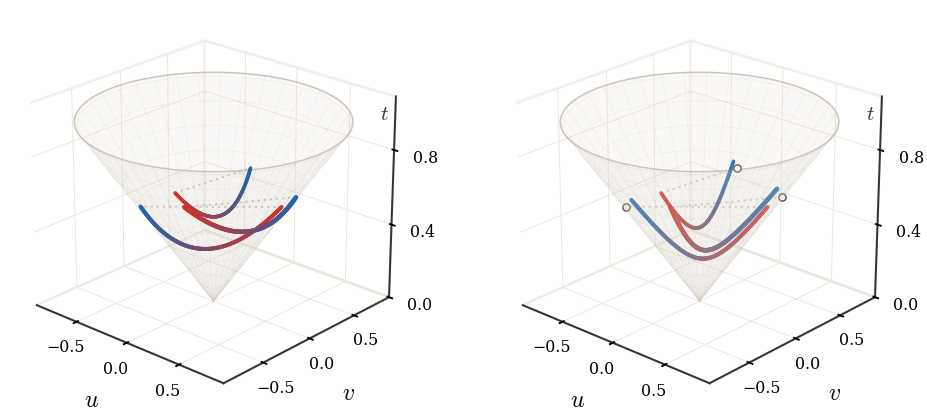

In [3]:
from IPython.display import Image, display
display(Image(filename=str(THUMBNAIL)))